<a href="https://colab.research.google.com/github/rubenoliva-dominguez/curso_cartagena/blob/main/dia1/3_regularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
import copy
import matplotlib.pyplot as plt

# Definición de la red

In [2]:
# Vamos a añadir una capa lineal oculta con función de activación ReLU
class IrisMLP(nn.Module):
    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.relu(self.fc1(x))   # (B, 16)
        logits = self.fc2(h)         # (B, 3)
        return logits

# Dataset y Dataloader

In [3]:
class IrisDataset(Dataset):
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
full_iris_dataset = IrisDataset()
train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(full_iris_dataset, [0.7, 0.2, 0.1], generator=torch.Generator().manual_seed(42))

In [5]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Ejercicio 1

Haz el entrenamiento de la red durante 100 epochs, reportando el loss de entrenamiento en cada epoch. Finalmente dibuja la gráfica del loss de entrenamiento a lo largo de las epochs.

Epoch 001 | train_loss = 1.1777
Epoch 002 | train_loss = 1.0422
Epoch 003 | train_loss = 0.9842
Epoch 004 | train_loss = 0.9454
Epoch 005 | train_loss = 0.9130
Epoch 006 | train_loss = 0.8848
Epoch 007 | train_loss = 0.8563
Epoch 008 | train_loss = 0.8327
Epoch 009 | train_loss = 0.8070
Epoch 010 | train_loss = 0.7831
Epoch 011 | train_loss = 0.7599
Epoch 012 | train_loss = 0.7352
Epoch 013 | train_loss = 0.7145
Epoch 014 | train_loss = 0.6894
Epoch 015 | train_loss = 0.6690
Epoch 016 | train_loss = 0.6481
Epoch 017 | train_loss = 0.6280
Epoch 018 | train_loss = 0.6113
Epoch 019 | train_loss = 0.5948
Epoch 020 | train_loss = 0.5798
Epoch 021 | train_loss = 0.5645
Epoch 022 | train_loss = 0.5527
Epoch 023 | train_loss = 0.5392
Epoch 024 | train_loss = 0.5295
Epoch 025 | train_loss = 0.5166
Epoch 026 | train_loss = 0.5099
Epoch 027 | train_loss = 0.4973
Epoch 028 | train_loss = 0.4889
Epoch 029 | train_loss = 0.4813
Epoch 030 | train_loss = 0.4720
Epoch 031 | train_loss = 0.4649
Epoch 03

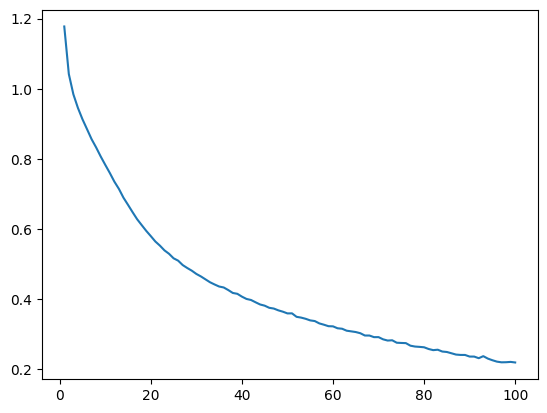

In [17]:
# Instanciamos el torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos el modelo y el loss
# En PyTorch, el loss y el modelo suelen ser instanciados por separado
model = IrisMLP()
criterion = nn.CrossEntropyLoss()


# Instanciamos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

# Iniciamos el entrenamiento
num_epochs = 100
train_losses = []
# durante un número de epochs
for epoch in range(1, num_epochs + 1):
    # poner el modelo en modo entrenamiento
    model.train()
    # para llevar la cuenta del loss
    running_loss = 0.0
    n_seen = 0
    for xB, yB in train_dataloader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen # loss medio en la epoch
    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f}") # reportamos el loss
    train_losses.append(epoch_loss)

plt.plot(range(1, num_epochs+1), train_losses)
plt.show()


# Ejercicio 2

Antes de finalizar cada epoch, obtén el loss de validación. Haz otra gráfica que muestre ambos losses. Interpreta la gráfica.

Epoch 001 | train_loss = 1.2935 | eval_loss = 0.1849
Epoch 002 | train_loss = 1.0426 | eval_loss = 0.1544
Epoch 003 | train_loss = 0.9810 | eval_loss = 0.1397
Epoch 004 | train_loss = 0.9525 | eval_loss = 0.1338
Epoch 005 | train_loss = 0.9152 | eval_loss = 0.1378
Epoch 006 | train_loss = 0.8878 | eval_loss = 0.1352
Epoch 007 | train_loss = 0.8605 | eval_loss = 0.1263
Epoch 008 | train_loss = 0.8441 | eval_loss = 0.1224
Epoch 009 | train_loss = 0.8128 | eval_loss = 0.1246
Epoch 010 | train_loss = 0.7964 | eval_loss = 0.1166
Epoch 011 | train_loss = 0.7715 | eval_loss = 0.1181
Epoch 012 | train_loss = 0.7508 | eval_loss = 0.1112
Epoch 013 | train_loss = 0.7301 | eval_loss = 0.1102
Epoch 014 | train_loss = 0.7064 | eval_loss = 0.1047
Epoch 015 | train_loss = 0.6938 | eval_loss = 0.1062
Epoch 016 | train_loss = 0.6740 | eval_loss = 0.1091
Epoch 017 | train_loss = 0.6524 | eval_loss = 0.1040
Epoch 018 | train_loss = 0.6380 | eval_loss = 0.1037
Epoch 019 | train_loss = 0.6205 | eval_loss = 

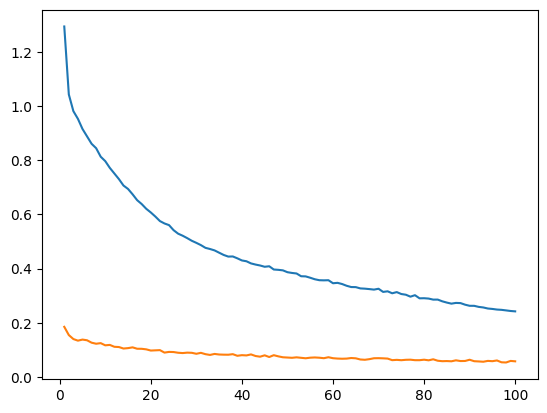

In [26]:
# Instanciamos el torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos el modelo y el loss
# En PyTorch, el loss y el modelo suelen ser instanciados por separado
model = IrisMLP()
criterion = nn.CrossEntropyLoss()


# Instanciamos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

# Iniciamos el entrenamiento
num_epochs = 100
train_losses = []
eval_losses = []
# durante un número de epochs
for epoch in range(1, num_epochs + 1):
    # poner el modelo en modo entrenamiento
    model.train()
    # para llevar la cuenta del loss
    running_loss = 0.0
    n_seen = 0
    n_seen_val = 0
    for xB, yB in train_dataloader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen
    # poner el modelo en modo validación
    model.eval()
    eval_loss = 0.0
    with torch.no_grad():
        for xB, yB in val_dataloader:
          xB, yB = xB.to(device), yB.to(device)
          logits = model(xB)         # forward
          loss = criterion(logits, yB)
          eval_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
          n_seen_val += xB.size(0)           # para llevar la cuenta del loss
    epocheval_loss = eval_loss / n_seen # loss medio en la epoch
    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f} | eval_loss = {epocheval_loss:.4f}") # reportamos el loss
    train_losses.append(epoch_loss)
    eval_losses.append(epocheval_loss)

plt.plot(range(1, num_epochs+1), train_losses, range(1, num_epochs+1), eval_losses)
plt.show()

# Ejercicio 3

Escoge una de estas dos opciones:
- Implementa early stopping con X epochs de paciencia.
- Implementa un mecanismo de guardar el mejor modelo y monitorización del loss de validación durante el entrenamiento.

**Nota.** Para guardar y restaurar el estado de la red:
```python
best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
```

# Ejercicio 4

Evalúa la mejor red obtenida en el apartado anterior. Usa `accuracy` como métrica.

In [ ]:
def evaluate_accuracy(loader, model, device):
    # TODO
    pass

accuracy = evaluate_accuracy(test_dataloader, model, device)
print(f"Accuracy en el conjunto de test: {accuracy:.2f}%")

# Ejercicio 5

Aumenta la hidden dimension a 1024 e implementa algún método de regularización visto en clase ($L_1,L_2$ o dropout).
- [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- [`weight_decay`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- Para $L_1$ hay que hacerla a mano, añadiendo la norma $L_1$ de los parámetros al loss.
